# AIRO Neural Networks Example
## MedMNIST Pneumonia Classification
### ANN vs. CNN
### Created by Caden Wondell

We will compare:

1. **Fully Connected Artificial Neural Network (ANN / MLP)**
2. **Convolutional Neural Network (CNN)**

**Dataset:** `PneumoniaMNIST` from MedMNIST

**Goal:** Classify pediatric chest X-ray images as:

- **0 = Normal**
- **1 = Pneumonia**

The same official train, validation, and test splits will be used for both models.

The comparison is designed to show the architectural difference:

- The **ANN flattens the image** into a 1D vector and learns position-specific connections.
- The **CNN keeps the 2D image structure**, learns local filters, and reuses those filters across the image.

MedMNIST provides standardized biomedical image datasets and official train/validation/test splits. PneumoniaMNIST contains 5,856 grayscale pediatric chest X-ray images resized to 28×28 pixels.

**Official project:** https://medmnist.com/

> **Important:** MedMNIST is intended for research and education, not clinical use.

## Step 1: Install the Required Package

Install `medmnist`.

The dataset will download automatically through the MedMNIST API, so no Google Drive mounting is required.

In [1]:
%pip -q install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.6 MB/s eta 0:00:00


## Step 2: Import the Libraries

Import the libraries needed to:

- Load PneumoniaMNIST
- Build the ANN and CNN
- Train both models with PyTorch
- Evaluate predictions
- Compare model performance

In [2]:
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

import medmnist
from medmnist import INFO

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

## Step 3: Set the Random Seed and Device

Use a fixed random seed so the example is easier to reproduce.

If a GPU is available, PyTorch will use it automatically.

In [3]:
SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        SEED
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    DEVICE
)

Device: cuda


## Step 4: Select PneumoniaMNIST

Use the MedMNIST metadata to identify the correct Python dataset class.

PneumoniaMNIST is a **binary image-classification** dataset:

- `0 = normal`
- `1 = pneumonia`

The images are grayscale.

In [4]:
DATA_FLAG = "pneumoniamnist"
IMAGE_SIZE = 224

info = INFO[
    DATA_FLAG
]

DataClass = getattr(
    medmnist,
    info["python_class"]
)

LABEL_MAP = {
    int(key): value
    for key, value
    in info["label"].items()
}

CLASS_NAMES = [
    LABEL_MAP[index]
    for index
    in sorted(LABEL_MAP)
]

NUM_CLASSES = len(
    CLASS_NAMES
)

NUM_CHANNELS = int(
    info["n_channels"]
)

print(
    "Dataset:",
    DATA_FLAG
)

print(
    "Task:",
    info["task"]
)

print(
    "Channels:",
    NUM_CHANNELS
)

print(
    "Classes:",
    LABEL_MAP
)

print(
    "Official sample counts:",
    info["n_samples"]
)

Dataset: pneumoniamnist
Task: binary-class
Channels: 1
Classes: {0: 'normal', 1: 'pneumonia'}
Official sample counts: {'train': 4708, 'val': 524, 'test': 624}


## Step 5: Define the Image Preprocessing

Both the ANN and CNN must receive the **same image values** for a fair comparison.

We will:

1. Convert each image to a PyTorch tensor.
2. Normalize pixel values from approximately `[0, 1]` to `[-1, 1]`.

No data augmentation is used in this teaching example so the architecture is the main difference between the models.

In [5]:
channel_means = [
    0.5
] * NUM_CHANNELS

channel_stds = [
    0.5
] * NUM_CHANNELS

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=channel_means,
        std=channel_stds
    )
])

transform

Compose(
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)

## Step 6: Load the Official Train, Validation, and Test Splits

MedMNIST provides predefined splits.

Using the official splits prevents us from manually reshuffling the data differently for the ANN and CNN.

In [6]:
train_dataset = DataClass(
    split="train",
    transform=transform,
    download=True,
    size=IMAGE_SIZE
)

val_dataset = DataClass(
    split="val",
    transform=transform,
    download=True,
    size=IMAGE_SIZE
)

test_dataset = DataClass(
    split="test",
    transform=transform,
    download=True,
    size=IMAGE_SIZE
)

print(
    "Training images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

print(
    "Testing images:",
    len(test_dataset)
)

100%|██████████| 214M/214M [01:10<00:00, 3.04MB/s]


Training images: 4708
Validation images: 524
Testing images: 624


## Step 7: Inspect One Image and Label

Look at the tensor shape of one chest X-ray.

For PneumoniaMNIST, each image should have shape:

`1 × 224 × 224`

That means:

- 1 grayscale channel
- 28 pixels high
- 28 pixels wide

In [7]:
sample_image, sample_label = (
    train_dataset[0]
)

print(
    "Image tensor shape:",
    sample_image.shape
)

print(
    "Raw label:",
    sample_label
)

sample_label_value = int(
    np.asarray(
        sample_label
    ).reshape(-1)[0]
)

print(
    "Class name:",
    CLASS_NAMES[
        sample_label_value
    ]
)

Image tensor shape: torch.Size([1, 224, 224])
Raw label: [1]
Class name: pneumonia


## Step 8: Visualize Training Images

Display several images from the training set.

We are using the 224×224 MedMNIST+ version so the architectural difference between a fully connected ANN and a CNN is easier to see.

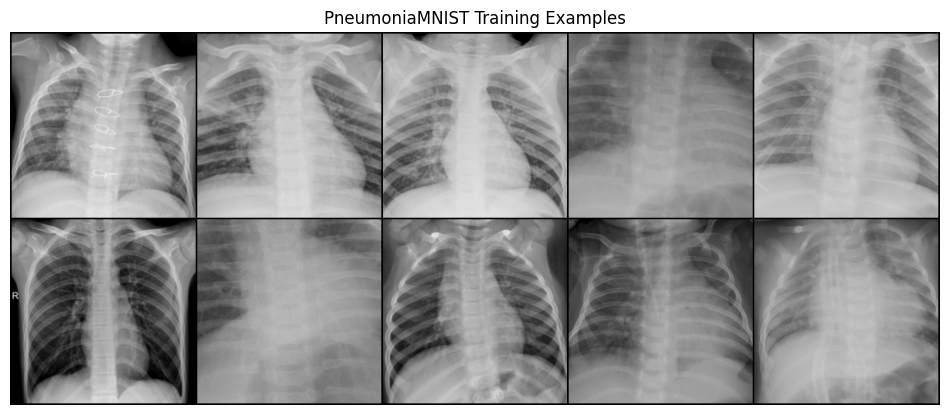

Labels:
['pneumonia', 'pneumonia', 'pneumonia', 'pneumonia', 'pneumonia', 'normal', 'pneumonia', 'normal', 'pneumonia', 'pneumonia']


In [8]:
sample_count = 10

sample_images = []

sample_labels = []

for index in range(
    sample_count
):
    image, label = (
        train_dataset[index]
    )

    sample_images.append(
        image
    )

    sample_labels.append(
        int(
            np.asarray(
                label
            ).reshape(-1)[0]
        )
    )

image_batch = torch.stack(
    sample_images
)

display_batch = (
    image_batch
    * 0.5
    + 0.5
)

image_grid = make_grid(
    display_batch,
    nrow=5,
    padding=2
)

plt.figure(
    figsize=(12, 5)
)

plt.imshow(
    image_grid
    .permute(
        1,
        2,
        0
    )
    .cpu()
    .numpy()
)

plt.axis(
    "off"
)

plt.title(
    "PneumoniaMNIST Training Examples"
)

plt.show()

print(
    "Labels:"
)

print([
    CLASS_NAMES[label]
    for label
    in sample_labels
])

## Step 9: Examine the Training Class Distribution

Medical datasets are often imbalanced.

Count the Normal and Pneumonia images in the training set before choosing the loss function.

In [9]:
train_labels = (
    np.asarray(
        train_dataset.labels
    )
    .reshape(-1)
    .astype(int)
)

class_counts = (
    pd.Series(
        train_labels
    )
    .value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame({
    "Class": [
        CLASS_NAMES[index]
        for index
        in class_counts.index
    ],
    "Count": class_counts.values
})

class_distribution

,Class,Count
0,normal,1214
1,pneumonia,3494


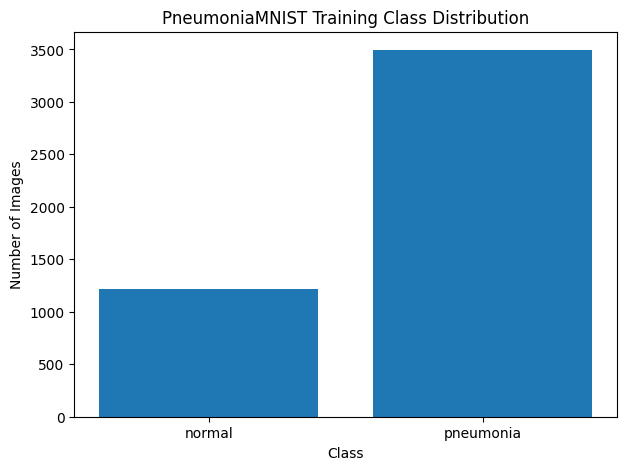

In [10]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title(
    "PneumoniaMNIST Training Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Images"
)

plt.show()

## Step 10: Create the DataLoaders

A DataLoader sends images to the model in small batches.

The **training loader is shuffled**.

Validation and test loaders are not shuffled because they are only used for evaluation.

In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Training batches: 74
Validation batches: 9
Testing batches: 10


## Step 11: Inspect One Batch

A batch of CNN inputs has four dimensions:

`batch × channels × height × width`

The ANN will later flatten each image into a single vector.

In [12]:
batch_images, batch_labels = next(
    iter(
        train_loader
    )
)

print(
    "Image batch shape:",
    batch_images.shape
)

print(
    "Label batch shape:",
    batch_labels.shape
)

Image batch shape: torch.Size([64, 1, 224, 224])
Label batch shape: torch.Size([64, 1])


## Step 12: Compare How the ANN and CNN Receive the Same Image

This is the central architectural difference.

### ANN

The 2D image is flattened:

`1 × 224 × 224 → 50,176 values`

The ANN receives one long vector, so the spatial layout is no longer explicitly represented by the architecture.

### CNN

The image remains:

`1 × 224 × 224`

The CNN uses local 3×3 filters, reuses the same filter weights across the image, and preserves spatial relationships between neighboring pixels.

In [13]:
example_batch = (
    batch_images[:4]
)

ann_input = (
    example_batch
    .view(
        example_batch.size(0),
        -1
    )
)

cnn_input = (
    example_batch
)

print(
    "CNN input shape:",
    cnn_input.shape
)

print(
    "ANN input shape after flattening:",
    ann_input.shape
)

CNN input shape: torch.Size([4, 1, 224, 224])
ANN input shape after flattening: torch.Size([4, 50176])


## Step 13: Calculate Class Weights

Because the classes are not perfectly balanced, use the training-set class frequencies to create class weights.

The **same weighted loss function** will be used for both the ANN and CNN.

In [14]:
training_counts = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

class_weights = (
    len(train_labels)
    / (
        NUM_CLASSES
        * training_counts
    )
)

class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print(
    "Training class counts:",
    training_counts
)

print(
    "Class weights:",
    class_weights
)

Training class counts: [1214 3494]
Class weights: [1.93904448 0.67372639]


## Step 14: Create the Shared Loss Function

Both models will use weighted Cross-Entropy Loss.

This keeps the loss function identical so the main comparison remains **ANN architecture vs. CNN architecture**.

In [15]:
criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)

criterion

CrossEntropyLoss()

## Step 15: Create a Parameter-Counting Function

Count the trainable parameters in each model.

This helps us compare architecture as well as predictive performance.

In [16]:
def count_trainable_parameters(
    model
):
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )

## Step 16: Create the Training and Validation Functions

Each model will use the exact same training process.

For every batch:

1. Make a forward pass.
2. Calculate the loss.
3. Backpropagate the gradients.
4. Update the weights.

In [17]:
def run_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None
):

    training = (
        optimizer
        is not None
    )

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in data_loader:

        images = images.to(
            DEVICE
        )

        labels = (
            labels
            .view(-1)
            .long()
            .to(
                DEVICE
            )
        )

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            training
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

            if training:
                loss.backward()

                optimizer.step()

        predictions = (
            logits
            .argmax(
                dim=1
            )
        )

        batch_size = (
            images.size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_correct += int(
            (
                predictions
                == labels
            )
            .sum()
            .item()
        )

        total_examples += (
            batch_size
        )

    average_loss = (
        total_loss
        / total_examples
    )

    accuracy = (
        total_correct
        / total_examples
    )

    return (
        average_loss,
        accuracy
    )

## Step 17: Create a Shared Model Training Function

Both models will use:

- Adam optimizer
- The same learning rate
- The same number of epochs
- The same validation split

The model state with the **lowest validation loss** is restored at the end.

In [18]:
LEARNING_RATE = 0.001
EPOCHS = 10

def train_model(
    model,
    model_name
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = []

    best_validation_loss = float(
        "inf"
    )

    best_state = copy.deepcopy(
        model.state_dict()
    )

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        train_loss, train_accuracy = (
            run_epoch(
                model,
                train_loader,
                criterion,
                optimizer=optimizer
            )
        )

        validation_loss, validation_accuracy = (
            run_epoch(
                model,
                val_loader,
                criterion,
                optimizer=None
            )
        )

        history.append({
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Validation Loss": validation_loss,
            "Train Accuracy": train_accuracy,
            "Validation Accuracy": validation_accuracy
        })

        if (
            validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                validation_loss
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"{model_name} | "
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Train Acc: {train_accuracy:.3f} | "
            f"Val Acc: {validation_accuracy:.3f}"
        )

    model.load_state_dict(
        best_state
    )

    history = pd.DataFrame(
        history
    )

    return (
        model,
        history
    )

## Step 18: Create a Shared Prediction Function

Use the trained model to collect:

- Actual labels
- Predicted labels
- Pneumonia probabilities

In [19]:
def collect_predictions(
    model,
    data_loader
):

    model.eval()

    all_labels = []

    all_predictions = []

    all_probabilities = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(
                DEVICE
            )

            labels = (
                labels
                .view(-1)
                .long()
            )

            logits = model(
                images
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = (
                probabilities
                .argmax(
                    dim=1
                )
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
                .tolist()
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
                .tolist()
            )

            all_probabilities.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
                .tolist()
            )

    return (
        np.asarray(
            all_labels
        ),
        np.asarray(
            all_predictions
        ),
        np.asarray(
            all_probabilities
        )
    )

## Step 19: Create a Shared Metrics Function

For each model, calculate:

- Accuracy
- Precision
- Recall
- F1
- AUROC

For this binary task, the positive class is **Pneumonia**.

In [20]:
def calculate_metrics(
    y_true,
    y_pred,
    y_probability
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "AUROC": roc_auc_score(
            y_true,
            y_probability
        )
    }

# Fully Connected ANN

## Step 20: Create the ANN Model

The ANN first **flattens** the image.

For a grayscale 224×224 image:

`1 × 224 × 224 → 50,176`

The ANN then uses fully connected layers.

Because every flattened pixel position gets its own connections, the first dense layer alone requires millions of weights.

The architecture does not automatically reuse the same learned detector at different image locations.

In [21]:
class ANNClassifier(
    nn.Module
):

    def __init__(
        self,
        image_size,
        channels,
        num_classes
    ):

        super().__init__()

        input_features = (
            image_size
            * image_size
            * channels
        )

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(
                input_features,
                128
            ),
            nn.ReLU(),
            nn.Dropout(
                0.20
            ),
            nn.Linear(
                128,
                64
            ),
            nn.ReLU(),
            nn.Dropout(
                0.20
            ),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(
        self,
        x
    ):

        x = self.flatten(
            x
        )

        return self.network(
            x
        )


ann_model = ANNClassifier(
    image_size=IMAGE_SIZE,
    channels=NUM_CHANNELS,
    num_classes=NUM_CLASSES
).to(
    DEVICE
)

ann_model

ANNClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

## Step 21: Count the ANN Parameters

Record the number of trainable parameters before training.

In [22]:
ann_parameter_count = (
    count_trainable_parameters(
        ann_model
    )
)

print(
    "ANN trainable parameters:",
    f"{ann_parameter_count:,}"
)

ANN trainable parameters: 6,431,042


## Step 22: Train the ANN

Train the fully connected ANN using the shared training settings.

In [23]:
ann_model, ann_history = (
    train_model(
        ann_model,
        "ANN"
    )
)

ANN | Epoch 01/10 | Train Loss: 0.2962 | Val Loss: 0.1699 | Train Acc: 0.888 | Val Acc: 0.929
ANN | Epoch 02/10 | Train Loss: 0.1670 | Val Loss: 0.1540 | Train Acc: 0.933 | Val Acc: 0.952
ANN | Epoch 03/10 | Train Loss: 0.1545 | Val Loss: 0.1468 | Train Acc: 0.941 | Val Acc: 0.937
ANN | Epoch 04/10 | Train Loss: 0.1354 | Val Loss: 0.1442 | Train Acc: 0.949 | Val Acc: 0.920
ANN | Epoch 05/10 | Train Loss: 0.1171 | Val Loss: 0.1268 | Train Acc: 0.954 | Val Acc: 0.952
ANN | Epoch 06/10 | Train Loss: 0.1083 | Val Loss: 0.1507 | Train Acc: 0.961 | Val Acc: 0.947
ANN | Epoch 07/10 | Train Loss: 0.0968 | Val Loss: 0.1540 | Train Acc: 0.965 | Val Acc: 0.945
ANN | Epoch 08/10 | Train Loss: 0.1001 | Val Loss: 0.1109 | Train Acc: 0.962 | Val Acc: 0.948
ANN | Epoch 09/10 | Train Loss: 0.0844 | Val Loss: 0.1249 | Train Acc: 0.968 | Val Acc: 0.948
ANN | Epoch 10/10 | Train Loss: 0.0789 | Val Loss: 0.2463 | Train Acc: 0.972 | Val Acc: 0.947


## Step 23: Plot the ANN Loss

Compare training loss with validation loss.

A growing gap between training and validation performance can indicate overfitting.

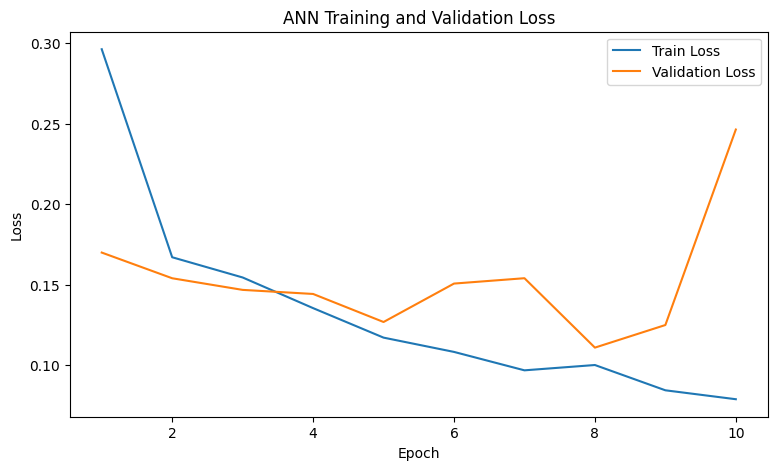

In [24]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    ann_history["Epoch"],
    ann_history["Train Loss"],
    label="Train Loss"
)

plt.plot(
    ann_history["Epoch"],
    ann_history["Validation Loss"],
    label="Validation Loss"
)

plt.title(
    "ANN Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

## Step 24: Plot the ANN Accuracy

Compare training accuracy with validation accuracy across epochs.

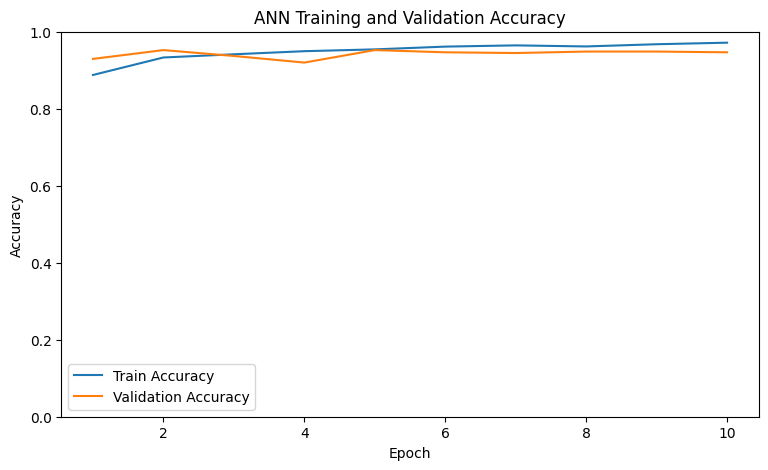

In [25]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    ann_history["Epoch"],
    ann_history["Train Accuracy"],
    label="Train Accuracy"
)

plt.plot(
    ann_history["Epoch"],
    ann_history["Validation Accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "ANN Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.show()

## Step 25: Make ANN Test Predictions

Evaluate the trained ANN on the untouched test set.

In [26]:
ann_y_true, ann_predictions, ann_probabilities = (
    collect_predictions(
        ann_model,
        test_loader
    )
)

ann_predictions[:10]

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1])

## Step 26: View the ANN Confusion Matrix

Compare the ANN predictions with the true Normal and Pneumonia labels.

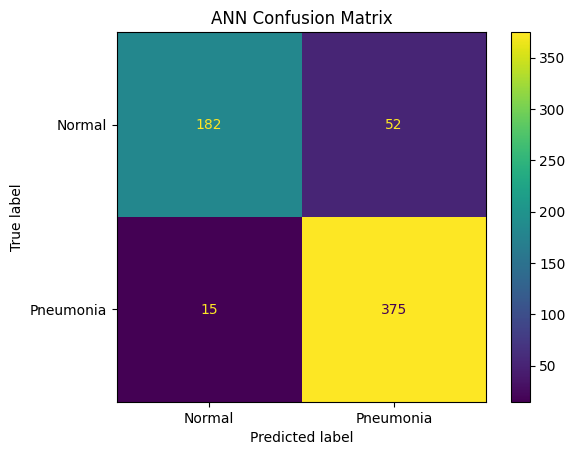

In [27]:
ConfusionMatrixDisplay.from_predictions(
    ann_y_true,
    ann_predictions,
    display_labels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.title(
    "ANN Confusion Matrix"
)

plt.show()

## Step 27: View the ANN Classification Metrics

View precision, recall, F1 score, and overall accuracy.

In [28]:
print(
    classification_report(
        ann_y_true,
        ann_predictions,
        target_names=[
            "Normal",
            "Pneumonia"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.92      0.78      0.84       234
   Pneumonia       0.88      0.96      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.87      0.88       624
weighted avg       0.90      0.89      0.89       624



## Step 28: Save the ANN Results

Save the test metrics so they can later be compared directly with the CNN.

In [29]:
ann_metrics = calculate_metrics(
    ann_y_true,
    ann_predictions,
    ann_probabilities
)

for metric_name, metric_value in ann_metrics.items():

    print(
        metric_name + ":",
        round(
            metric_value,
            3
        )
    )

Accuracy: 0.893
Precision: 0.878
Recall: 0.962
F1: 0.918
AUROC: 0.942


# Convolutional Neural Network

## Step 29: Create the CNN Model

Unlike the ANN, the CNN keeps the image in its 2D spatial form.

For the 224×224 images, the CNN repeatedly applies convolution and pooling:

`224 → 112 → 56 → 28 → 14`

The CNN uses:

1. Convolution → ReLU → Max Pooling
2. Convolution → ReLU → Max Pooling
3. Convolution → ReLU → Max Pooling
4. Convolution → ReLU → Max Pooling
5. Flatten
6. Fully Connected Layer
7. Output Layer

The same convolutional filter is reused across many image locations.

This lets the CNN learn spatial features without immediately creating a separate weight for every pixel-to-neuron connection.

In [30]:
class CNNClassifier(
    nn.Module
):

    def __init__(
        self,
        channels,
        num_classes
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=channels,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.conv4 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            0.20
        )

        self.fc1 = nn.Linear(
            64 * 14 * 14,
            64
        )

        self.fc2 = nn.Linear(
            64,
            num_classes
        )

    def forward(
        self,
        x
    ):

        x = self.pool(
            self.relu(
                self.conv1(
                    x
                )
            )
        )

        x = self.pool(
            self.relu(
                self.conv2(
                    x
                )
            )
        )

        x = self.pool(
            self.relu(
                self.conv3(
                    x
                )
            )
        )

        x = self.pool(
            self.relu(
                self.conv4(
                    x
                )
            )
        )

        x = torch.flatten(
            x,
            1
        )

        x = self.fc1(
            x
        )

        x = self.relu(
            x
        )

        x = self.dropout(
            x
        )

        x = self.fc2(
            x
        )

        return x


cnn_model = CNNClassifier(
    channels=NUM_CHANNELS,
    num_classes=NUM_CLASSES
).to(
    DEVICE
)

cnn_model

CNNClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=12544, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

## Step 30: Follow the CNN Tensor Shapes

Pass one small batch through each major CNN operation.

With 224×224 inputs, max pooling progressively reduces the spatial dimensions:

`224 → 112 → 56 → 28 → 14`

At the same time, the convolutional layers increase the number of learned feature maps:

`1 → 16 → 32 → 64 → 64`

This is the key contrast with the ANN, which immediately flattens the 224×224 image into 50,176 separate input values.

In [31]:
shape_example = (
    batch_images[:2]
    .to(
        DEVICE
    )
)

with torch.no_grad():

    after_conv1 = (
        cnn_model
        .relu(
            cnn_model
            .conv1(
                shape_example
            )
        )
    )

    after_pool1 = (
        cnn_model
        .pool(
            after_conv1
        )
    )

    after_conv2 = (
        cnn_model
        .relu(
            cnn_model
            .conv2(
                after_pool1
            )
        )
    )

    after_pool2 = (
        cnn_model
        .pool(
            after_conv2
        )
    )

    after_conv3 = (
        cnn_model
        .relu(
            cnn_model
            .conv3(
                after_pool2
            )
        )
    )

    after_pool3 = (
        cnn_model
        .pool(
            after_conv3
        )
    )

    after_conv4 = (
        cnn_model
        .relu(
            cnn_model
            .conv4(
                after_pool3
            )
        )
    )

    after_pool4 = (
        cnn_model
        .pool(
            after_conv4
        )
    )

print(
    "Input:",
    shape_example.shape
)

print(
    "After Conv1:",
    after_conv1.shape
)

print(
    "After Pool1:",
    after_pool1.shape
)

print(
    "After Conv2:",
    after_conv2.shape
)

print(
    "After Pool2:",
    after_pool2.shape
)

print(
    "After Conv3:",
    after_conv3.shape
)

print(
    "After Pool3:",
    after_pool3.shape
)

print(
    "After Conv4:",
    after_conv4.shape
)

print(
    "After Pool4:",
    after_pool4.shape
)

print(
    "After Flatten:",
    torch.flatten(
        after_pool4,
        1
    ).shape
)

Input: torch.Size([2, 1, 224, 224])
After Conv1: torch.Size([2, 16, 224, 224])
After Pool1: torch.Size([2, 16, 112, 112])
After Conv2: torch.Size([2, 32, 112, 112])
After Pool2: torch.Size([2, 32, 56, 56])
After Conv3: torch.Size([2, 64, 56, 56])
After Pool3: torch.Size([2, 64, 28, 28])
After Conv4: torch.Size([2, 64, 28, 28])
After Pool4: torch.Size([2, 64, 14, 14])
After Flatten: torch.Size([2, 12544])


## Step 31: Count the ANN and CNN Parameters

The 224×224 image makes the architecture difference much easier to see.

### ANN

The ANN immediately flattens the image:

`224 × 224 = 50,176 inputs`

Its first dense layer therefore contains millions of separate position-specific weights.

### CNN

The CNN begins with small 3×3 filters whose weights are reused across the image.

Pooling then progressively reduces:

`224 → 112 → 56 → 28 → 14`

Compare the trainable parameter counts below.

In [32]:
cnn_parameter_count = (
    count_trainable_parameters(
        cnn_model
    )
)

print(
    "CNN trainable parameters:",
    f"{cnn_parameter_count:,}"
)

print()

print(
    "ANN trainable parameters:",
    f"{ann_parameter_count:,}"
)

CNN trainable parameters: 863,234

ANN trainable parameters: 6,431,042


## Step 32: Train the CNN

Train the CNN using the **same**:

- Training split
- Validation split
- Loss function
- Class weights
- Optimizer type
- Learning rate
- Number of epochs

used for the ANN.

In [33]:
cnn_model, cnn_history = (
    train_model(
        cnn_model,
        "CNN"
    )
)

CNN | Epoch 01/10 | Train Loss: 0.3432 | Val Loss: 0.1627 | Train Acc: 0.816 | Val Acc: 0.914
CNN | Epoch 02/10 | Train Loss: 0.1514 | Val Loss: 0.1048 | Train Acc: 0.940 | Val Acc: 0.964
CNN | Epoch 03/10 | Train Loss: 0.1126 | Val Loss: 0.1175 | Train Acc: 0.960 | Val Acc: 0.975
CNN | Epoch 04/10 | Train Loss: 0.0950 | Val Loss: 0.0911 | Train Acc: 0.964 | Val Acc: 0.969
CNN | Epoch 05/10 | Train Loss: 0.0822 | Val Loss: 0.0758 | Train Acc: 0.969 | Val Acc: 0.968
CNN | Epoch 06/10 | Train Loss: 0.0737 | Val Loss: 0.0829 | Train Acc: 0.970 | Val Acc: 0.968
CNN | Epoch 07/10 | Train Loss: 0.0676 | Val Loss: 0.0838 | Train Acc: 0.974 | Val Acc: 0.964
CNN | Epoch 08/10 | Train Loss: 0.0578 | Val Loss: 0.0738 | Train Acc: 0.978 | Val Acc: 0.966
CNN | Epoch 09/10 | Train Loss: 0.0515 | Val Loss: 0.1038 | Train Acc: 0.981 | Val Acc: 0.969
CNN | Epoch 10/10 | Train Loss: 0.0657 | Val Loss: 0.0902 | Train Acc: 0.976 | Val Acc: 0.956


## Step 33: Plot the CNN Loss

Compare training and validation loss across epochs.

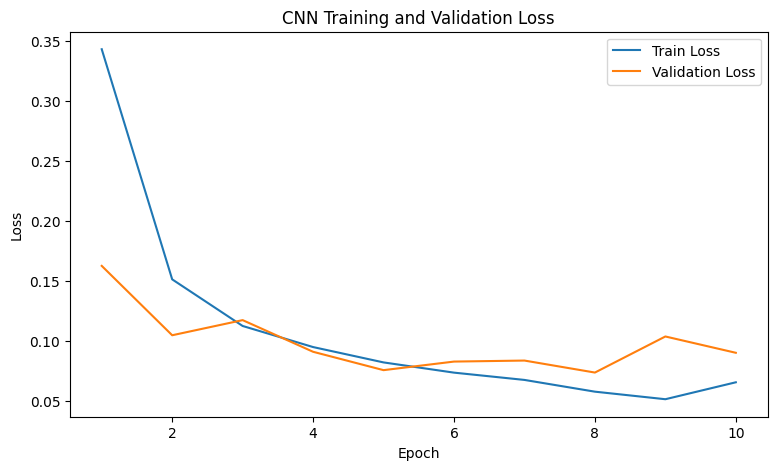

In [34]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    cnn_history["Epoch"],
    cnn_history["Train Loss"],
    label="Train Loss"
)

plt.plot(
    cnn_history["Epoch"],
    cnn_history["Validation Loss"],
    label="Validation Loss"
)

plt.title(
    "CNN Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

## Step 34: Plot the CNN Accuracy

Compare training and validation accuracy across epochs.

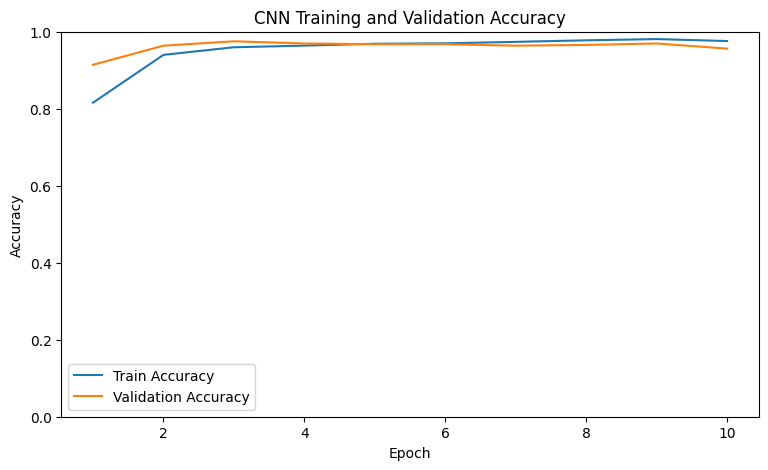

In [35]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    cnn_history["Epoch"],
    cnn_history["Train Accuracy"],
    label="Train Accuracy"
)

plt.plot(
    cnn_history["Epoch"],
    cnn_history["Validation Accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.show()

## Step 35: Make CNN Test Predictions

Evaluate the trained CNN on the exact same untouched test set used for the ANN.

In [36]:
cnn_y_true, cnn_predictions, cnn_probabilities = (
    collect_predictions(
        cnn_model,
        test_loader
    )
)

cnn_predictions[:10]

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1])

## Step 36: View the CNN Confusion Matrix

Compare the CNN predictions with the true Normal and Pneumonia labels.

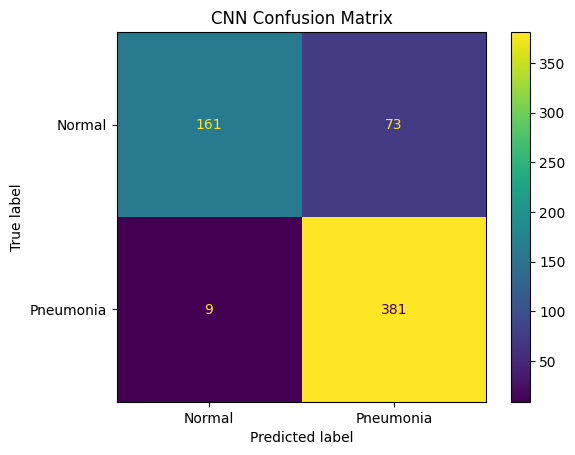

In [37]:
ConfusionMatrixDisplay.from_predictions(
    cnn_y_true,
    cnn_predictions,
    display_labels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

## Step 37: View the CNN Classification Metrics

View precision, recall, F1 score, and overall accuracy.

In [38]:
print(
    classification_report(
        cnn_y_true,
        cnn_predictions,
        target_names=[
            "Normal",
            "Pneumonia"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.95      0.69      0.80       234
   Pneumonia       0.84      0.98      0.90       390

    accuracy                           0.87       624
   macro avg       0.89      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



## Step 38: Save the CNN Results

Save the same metrics used for the ANN.

In [39]:
cnn_metrics = calculate_metrics(
    cnn_y_true,
    cnn_predictions,
    cnn_probabilities
)

for metric_name, metric_value in cnn_metrics.items():

    print(
        metric_name + ":",
        round(
            metric_value,
            3
        )
    )

Accuracy: 0.869
Precision: 0.839
Recall: 0.977
F1: 0.903
AUROC: 0.945


## Step 39: Visualize CNN Feature Maps

Look at several feature maps created by the **first convolutional layer** for one test image.

Each channel represents the response of a different learned filter.

These are not manually programmed edge detectors. Their values are learned during training.

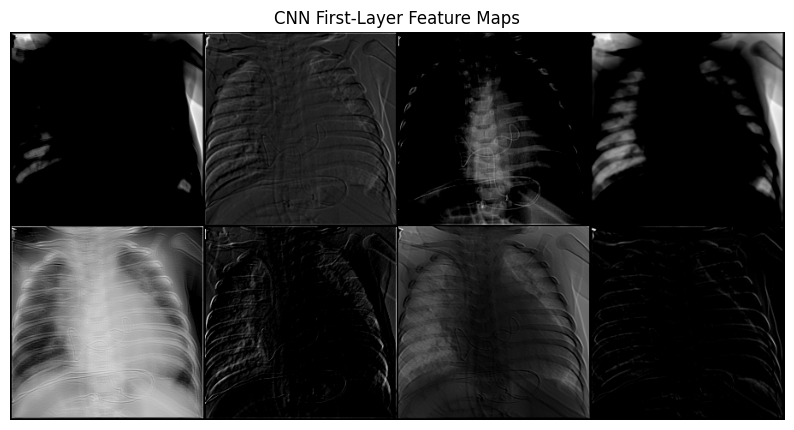

In [40]:
feature_image, feature_label = (
    test_dataset[0]
)

feature_input = (
    feature_image
    .unsqueeze(0)
    .to(
        DEVICE
    )
)

cnn_model.eval()

with torch.no_grad():

    first_feature_maps = (
        cnn_model
        .relu(
            cnn_model
            .conv1(
                feature_input
            )
        )
        .cpu()
        .squeeze(0)
    )

maps_to_show = (
    first_feature_maps[:8]
    .unsqueeze(1)
)

feature_grid = make_grid(
    maps_to_show,
    nrow=4,
    normalize=True,
    scale_each=True,
    padding=2
)

plt.figure(
    figsize=(10, 6)
)

plt.imshow(
    feature_grid
    .permute(
        1,
        2,
        0
    )
    .numpy()
)

plt.axis(
    "off"
)

plt.title(
    "CNN First-Layer Feature Maps"
)

plt.show()

# Compare the Models

## Step 40: Compare ANN and CNN Metrics

Compare both models on the same test images.

The CNN is not automatically guaranteed to win every metric. The purpose is to observe what changes when spatial structure and convolution are introduced.

In [41]:
results = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "Accuracy": [
        ann_metrics["Accuracy"],
        cnn_metrics["Accuracy"]
    ],
    "Precision": [
        ann_metrics["Precision"],
        cnn_metrics["Precision"]
    ],
    "Recall": [
        ann_metrics["Recall"],
        cnn_metrics["Recall"]
    ],
    "F1": [
        ann_metrics["F1"],
        cnn_metrics["F1"]
    ],
    "AUROC": [
        ann_metrics["AUROC"],
        cnn_metrics["AUROC"]
    ]
})

results.round(
    3
)

,Model,Accuracy,Precision,Recall,F1,AUROC
0,ANN,0.893,0.878,0.962,0.918,0.942
1,CNN,0.869,0.839,0.977,0.903,0.945


## Step 41: Graph the Model Comparison

Plot the metrics so the ANN and CNN are easier to compare.

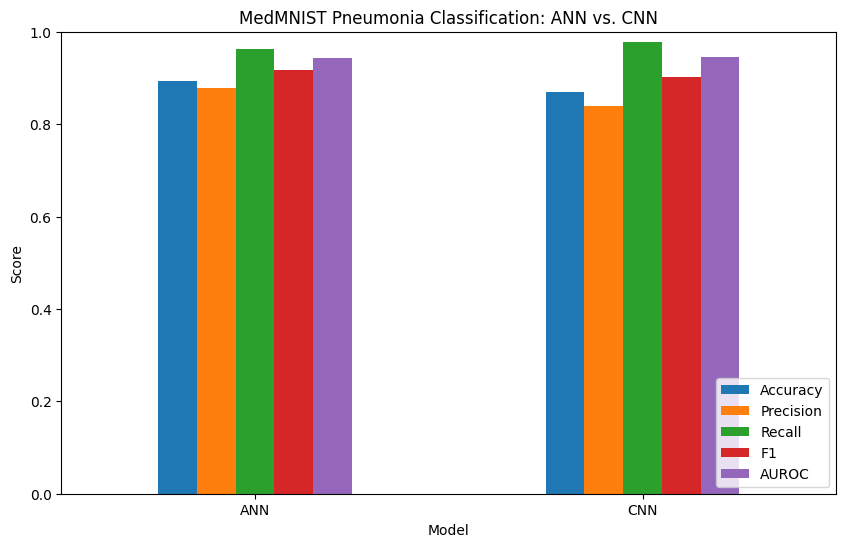

In [42]:
results_plot = (
    results
    .set_index(
        "Model"
    )
)

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "MedMNIST Pneumonia Classification: ANN vs. CNN"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.show()

## Step 42: Compare the ROC Curves

AUROC compares how well each model ranks Pneumonia images above Normal images across possible probability thresholds.

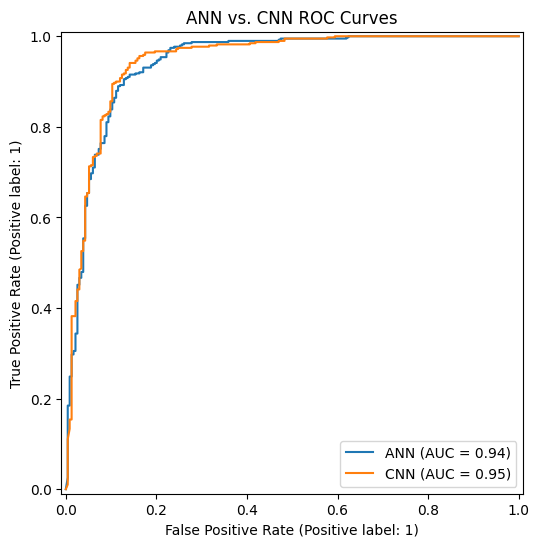

In [43]:
plt.figure(
    figsize=(8, 6)
)

ax = plt.gca()

RocCurveDisplay.from_predictions(
    ann_y_true,
    ann_probabilities,
    name="ANN",
    ax=ax
)

RocCurveDisplay.from_predictions(
    cnn_y_true,
    cnn_probabilities,
    name="CNN",
    ax=ax
)

plt.title(
    "ANN vs. CNN ROC Curves"
)

plt.show()

## Step 43: Compare False Negatives

A false negative is a Pneumonia image that the model classified as Normal.

This is worth examining separately from overall accuracy.

In [44]:
def false_negatives(
    y_true,
    y_pred
):

    return int(
        (
            (y_true == 1)
            & (y_pred == 0)
        )
        .sum()
    )


false_negative_results = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "False Negatives": [
        false_negatives(
            ann_y_true,
            ann_predictions
        ),
        false_negatives(
            cnn_y_true,
            cnn_predictions
        )
    ]
})

false_negative_results

,Model,False Negatives
0,ANN,15
1,CNN,9


## Step 44: Compare the Number of Trainable Parameters

Parameter count alone does not determine model quality.

The important difference is **how those parameters are connected and reused**.

- ANN: fully connected position-specific weights
- CNN: local filters with shared weights

In [45]:
parameter_results = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "Trainable Parameters": [
        ann_parameter_count,
        cnn_parameter_count
    ]
})

parameter_results

,Model,Trainable Parameters
0,ANN,6431042
1,CNN,863234


## Step 45: Predict the Same Test Image With Both Models

Use one Pneumonia-positive test image when available.

Compare the models on the **exact same image**.

In [46]:
test_labels_array = (
    np.asarray(
        test_dataset.labels
    )
    .reshape(-1)
    .astype(int)
)

positive_indices = np.where(
    test_labels_array == 1
)[0]

if len(
    positive_indices
) > 0:

    example_index = int(
        positive_indices[0]
    )

else:

    example_index = 0


example_image, example_label = (
    test_dataset[
        example_index
    ]
)

example_input = (
    example_image
    .unsqueeze(0)
    .to(
        DEVICE
    )
)

ann_model.eval()

cnn_model.eval()

with torch.no_grad():

    ann_output = ann_model(
        example_input
    )

    cnn_output = cnn_model(
        example_input
    )

    ann_probability = float(
        torch.softmax(
            ann_output,
            dim=1
        )[0, 1]
        .cpu()
        .item()
    )

    cnn_probability = float(
        torch.softmax(
            cnn_output,
            dim=1
        )[0, 1]
        .cpu()
        .item()
    )

    ann_prediction = int(
        ann_output
        .argmax(
            dim=1
        )
        .cpu()
        .item()
    )

    cnn_prediction = int(
        cnn_output
        .argmax(
            dim=1
        )
        .cpu()
        .item()
    )


actual_label = int(
    np.asarray(
        example_label
    ).reshape(-1)[0]
)

example_results = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "Prediction": [
        CLASS_NAMES[
            ann_prediction
        ],
        CLASS_NAMES[
            cnn_prediction
        ]
    ],
    "Pneumonia Probability": [
        ann_probability,
        cnn_probability
    ]
})

print(
    "Actual class:",
    CLASS_NAMES[
        actual_label
    ]
)

example_results

Actual class: pneumonia


,Model,Prediction,Pneumonia Probability
0,ANN,pneumonia,0.999952
1,CNN,pneumonia,0.999994


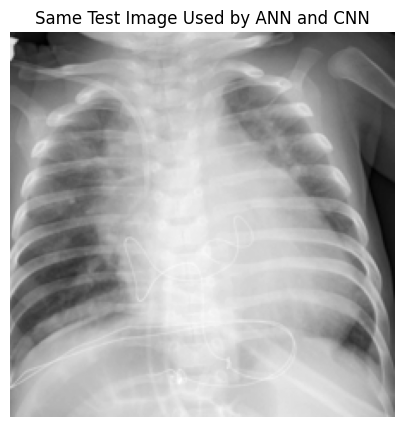

In [47]:
display_image = (
    example_image
    * 0.5
    + 0.5
)

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    display_image
    .squeeze(0)
    .cpu()
    .numpy(),
    cmap="gray"
)

plt.axis(
    "off"
)

plt.title(
    "Same Test Image Used by ANN and CNN"
)

plt.show()

# Discussion

After running the notebook, compare the two models:

- Which model had the higher Accuracy?
- Which model had the higher Recall for Pneumonia?
- Which model had the higher F1 score?
- Which model had the higher AUROC?
- Which model produced fewer false negatives?
- Did the CNN outperform the ANN on every metric?
- How different were the ANN and CNN parameter counts at 224×224?
- Why does the ANN flatten 224×224 into 50,176 separate inputs?
- What spatial information is easier for the CNN to use?
- Why can the CNN detect a learned local feature in different image regions?
- What does **weight sharing** mean?
- What did the first-layer CNN feature maps appear to respond to?
- Why does max pooling reduce the spatial size?
- Why does the CNN still use fully connected layers near the output?
- Why is accuracy alone not enough for a medical classification problem?

## Important Research Lesson

A CNN is still an artificial neural network.

The key difference is the architecture.

### ANN / MLP

- Flattens the image
- Uses fully connected layers
- Learns separate connections tied to input positions
- Does not explicitly preserve 2D spatial structure

### CNN

- Keeps the image in spatial form
- Uses small local filters
- Shares filter weights across locations
- Produces multiple feature maps
- Can build increasingly complex spatial features across layers

For a real medical-imaging research project, this notebook would only be a starting point.

Additional work would include:

- Larger image resolutions
- More robust augmentation
- Hyperparameter tuning
- Repeated experiments
- Calibration
- External validation
- Error analysis
- Bias/fairness analysis
- Explainability
- Comparison with stronger architectures such as ResNet
- Careful review of the original dataset collection process

**MedMNIST is intended for research and educational use and is not intended for clinical deployment.**